<a href="https://www.kaggle.com/code/lalit7881/maharashtra-climate-trends-2020-25-eda?scriptVersionId=314015857" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rosemeenshaikh/maharashtra-climate-trends-20202025/cities_weather_maharashtra.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/rosemeenshaikh/maharashtra-climate-trends-20202025/cities_weather_maharashtra.csv")

In [3]:
df.head()

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
0,2020-01-01 00:00:00,21.4,13.7,29.1,1.0,NaN,1014.5,NaN,Achalpur
1,2020-02-01 00:00:00,24.3,15.8,32.7,0.0,NaN,1013.9,NaN,Achalpur
2,2020-03-01 00:00:00,27.9,19.7,36.2,18.0,NaN,1010.1,NaN,Achalpur
3,2020-04-01 00:00:00,33.2,24.6,41.8,2.0,NaN,1006.3,NaN,Achalpur
4,2020-05-01 00:00:00,36.1,28.1,44.0,3.0,NaN,1002.8,NaN,Achalpur


In [4]:
df.tail()

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
2587,2025-08-01 00:00:00,25.8,23.4,29.6,370.0,NaN,1004.7,NaN,Yavatmal
2588,2025-09-01 00:00:00,25.4,22.9,29.2,266.7,NaN,1006.0,NaN,Yavatmal
2589,2025-10-01 00:00:00,25.6,22.0,30.0,84.9,NaN,1009.8,NaN,Yavatmal
2590,2025-11-01 00:00:00,21.7,16.7,27.2,3.3,NaN,1014.7,NaN,Yavatmal
2591,2025-12-01 00:00:00,19.4,13.5,26.2,0.0,NaN,1015.8,NaN,Yavatmal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    2592 non-null   object 
 1   tavg    2342 non-null   float64
 2   tmin    2340 non-null   float64
 3   tmax    2319 non-null   float64
 4   prcp    2270 non-null   float64
 5   wspd    0 non-null      float64
 6   pres    2314 non-null   float64
 7   tsun    926 non-null    float64
 8   city    2592 non-null   object 
dtypes: float64(7), object(2)
memory usage: 182.4+ KB


In [6]:
df.describe()

,tavg,tmin,tmax,prcp,wspd,pres,tsun
count,2342.000000,2340.000000,2319.000000,2270.000000,0.0,2314.000000,926.000000
mean,26.633689,21.414444,32.411212,128.161013,NaN,1008.985480,10813.606911
std,3.278812,3.756930,3.652044,220.355903,NaN,4.020499,4054.473266
min,18.400000,10.100000,25.400000,0.000000,NaN,998.700000,1020.000000
25%,24.300000,18.700000,29.800000,0.600000,NaN,1005.500000,7860.000000
50%,26.600000,21.900000,31.600000,25.000000,NaN,1009.100000,11520.000000
75%,28.700000,24.300000,34.250000,188.750000,NaN,1012.700000,14100.000000
max,36.500000,29.800000,44.000000,1768.900000,NaN,1016.100000,18900.000000


In [7]:
df.isnull().sum()

date       0
tavg     250
tmin     252
tmax     273
prcp     322
wspd    2592
pres     278
tsun    1666
city       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

date     object
tavg    float64
tmin    float64
tmax    float64
prcp    float64
wspd    float64
pres    float64
tsun    float64
city     object
dtype: object

In [10]:
df.shape

(2592, 9)

In [11]:
df.columns

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tsun', 'city'], dtype='object')

In [12]:
df.nunique()

date     72
tavg    165
tmin    168
tmax    170
prcp    752
wspd      0
pres    156
tsun    140
city     36
dtype: int64

## EDA

        date  tavg  tmin  tmax  prcp  wspd    pres  tsun      city
0 2020-01-01  21.4  13.7  29.1   1.0   NaN  1014.5   NaN  Achalpur
1 2020-02-01  24.3  15.8  32.7   0.0   NaN  1013.9   NaN  Achalpur
2 2020-03-01  27.9  19.7  36.2  18.0   NaN  1010.1   NaN  Achalpur
3 2020-04-01  33.2  24.6  41.8   2.0   NaN  1006.3   NaN  Achalpur
4 2020-05-01  36.1  28.1  44.0   3.0   NaN  1002.8   NaN  Achalpur
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2592 entries, 0 to 2591
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2592 non-null   datetime64[ns]
 1   tavg    2342 non-null   float64       
 2   tmin    2340 non-null   float64       
 3   tmax    2319 non-null   float64       
 4   prcp    2270 non-null   float64       
 5   wspd    0 non-null      float64       
 6   pres    2314 non-null   float64       
 7   tsun    926 non-null    float64       
 8   city    2592 non-null   object        
dtypes: 

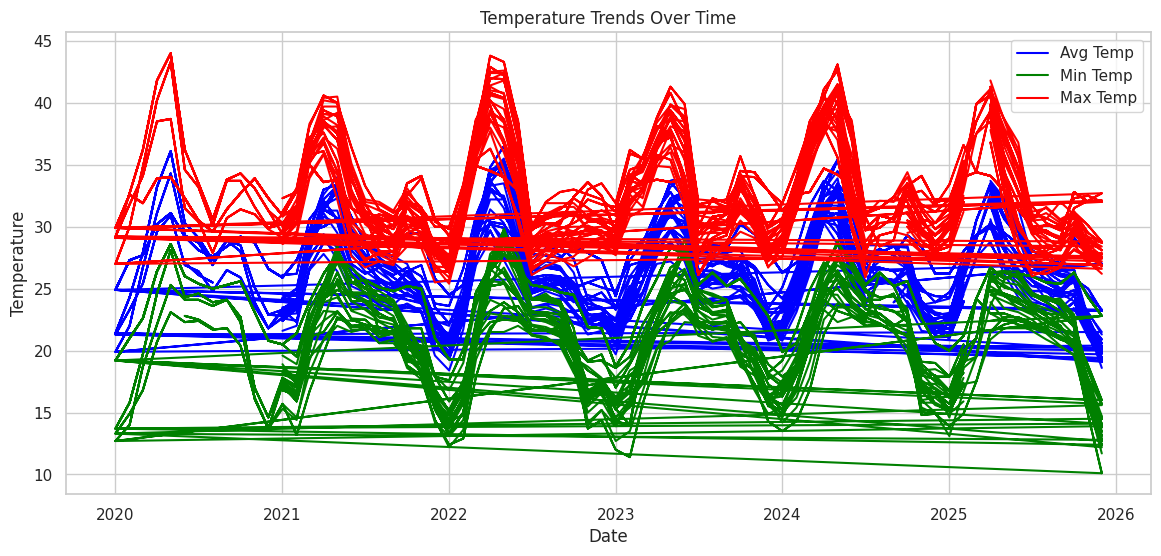

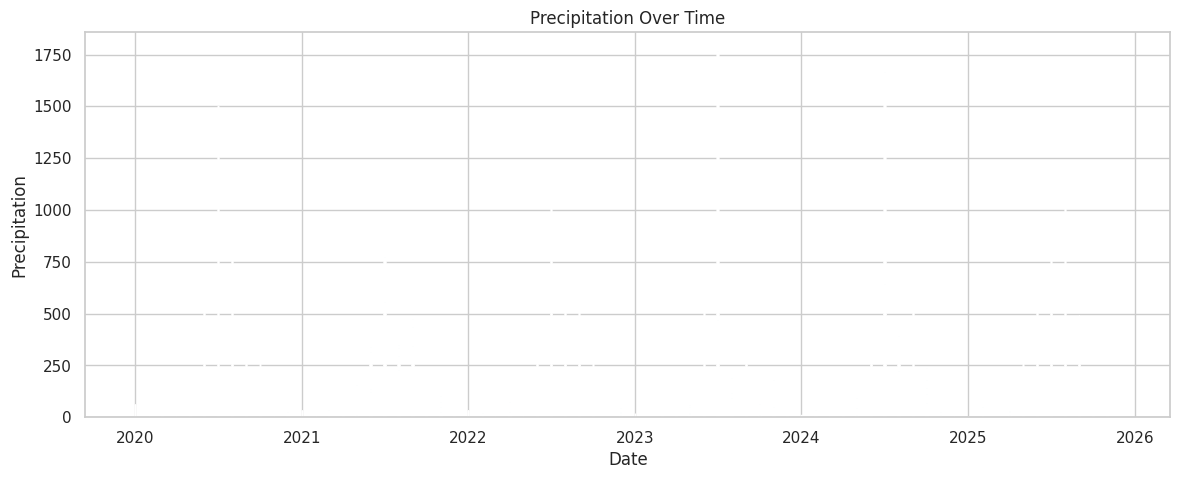

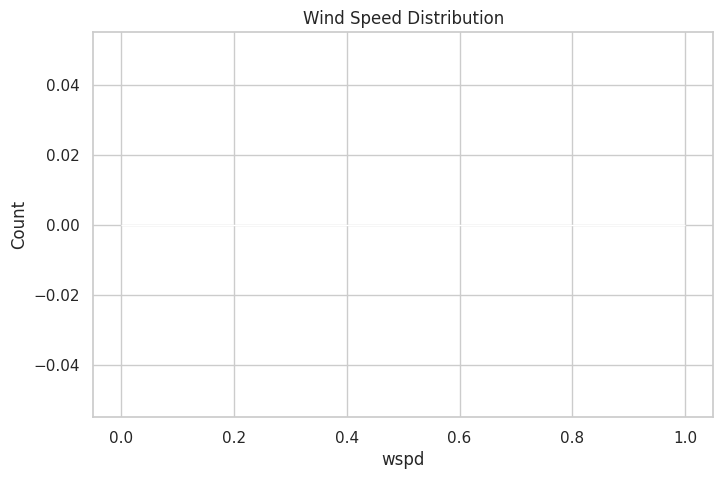

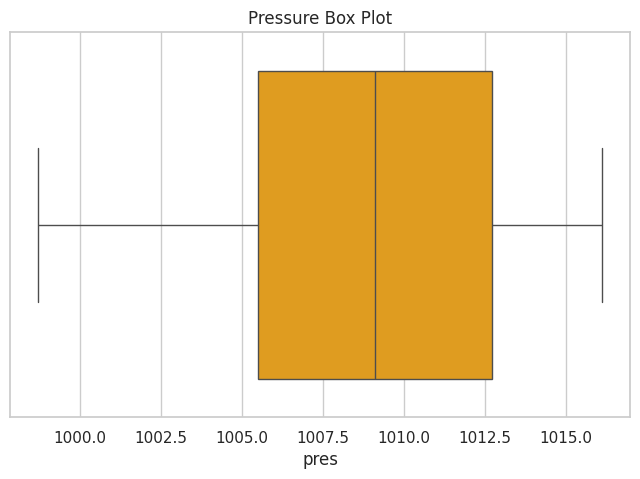

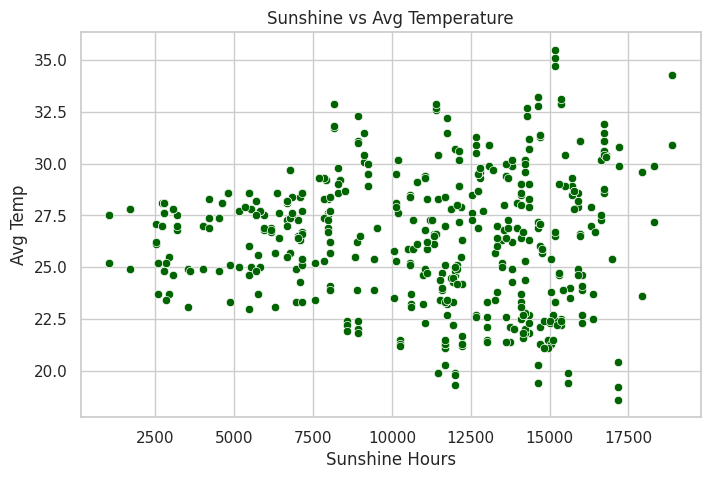

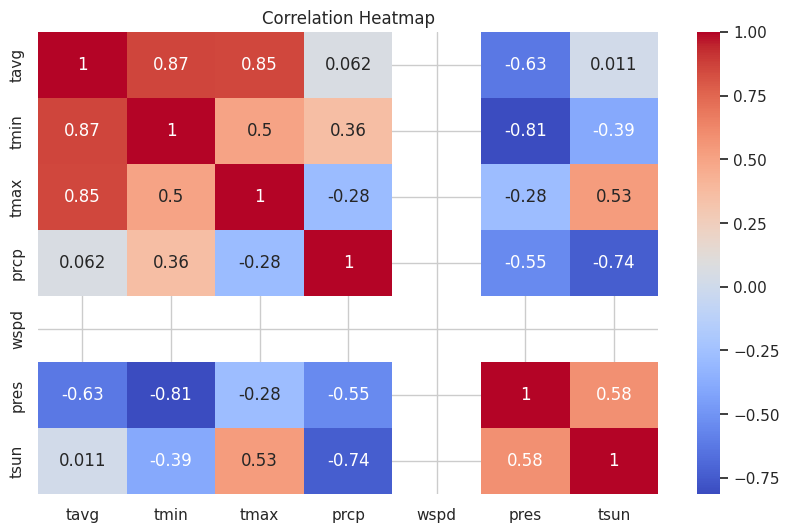

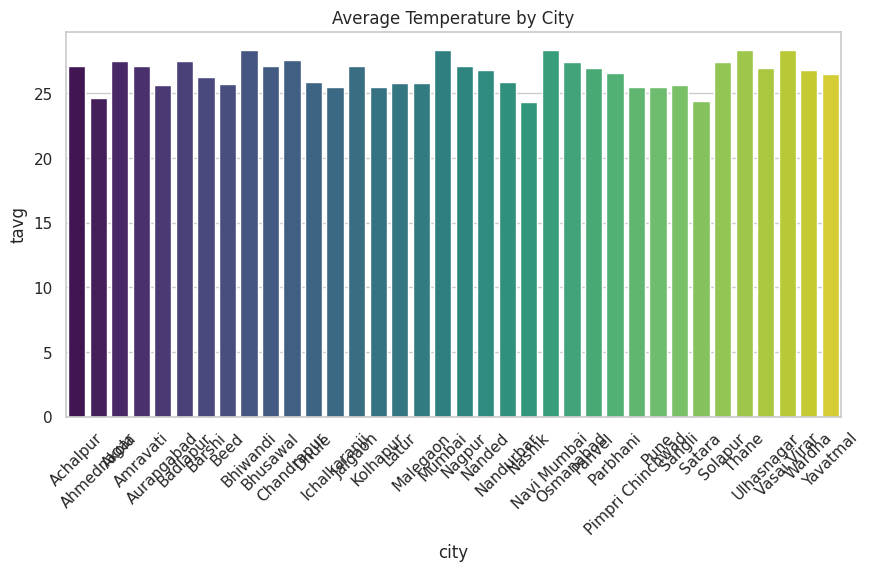

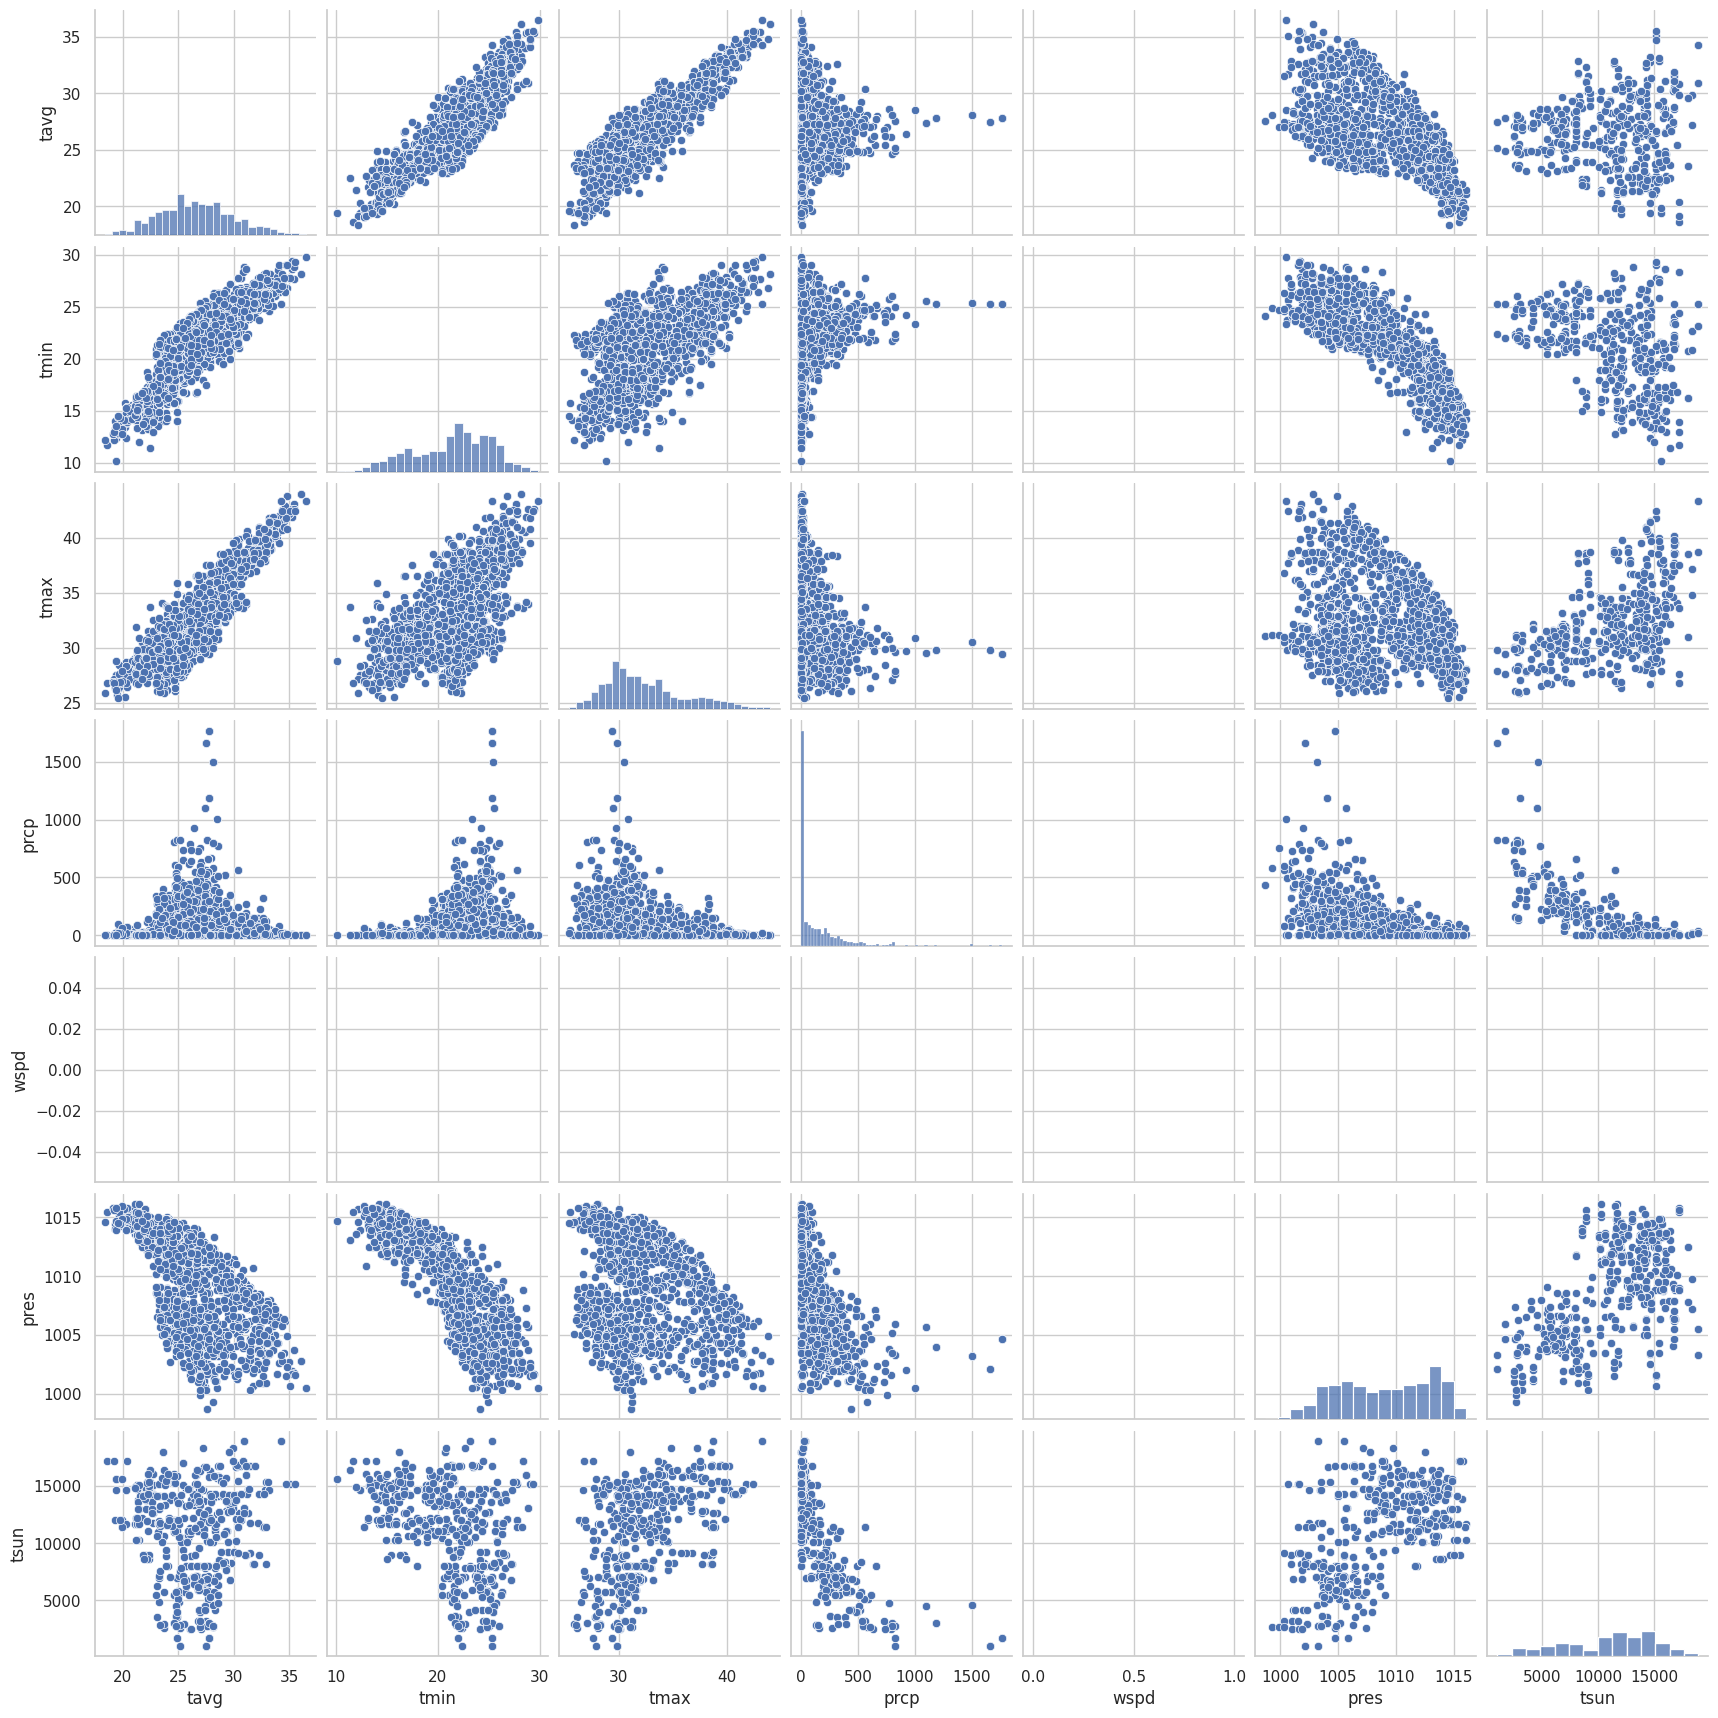

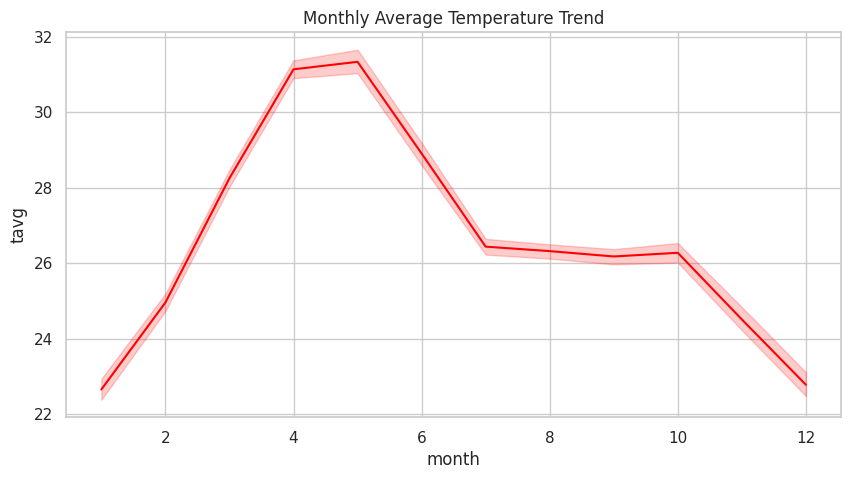

In [13]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# =========================
# BASIC INFO
# =========================
print(df.head())
print(df.info())

# =========================
# SET STYLE
# =========================
sns.set(style="whitegrid")

# =========================
# 1. TEMPERATURE TREND
# =========================
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['tavg'], color='blue', label='Avg Temp')
plt.plot(df['date'], df['tmin'], color='green', label='Min Temp')
plt.plot(df['date'], df['tmax'], color='red', label='Max Temp')
plt.title("Temperature Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# =========================
# 2. PRECIPITATION TREND
# =========================
plt.figure(figsize=(14,5))
plt.bar(df['date'], df['prcp'], color='skyblue')
plt.title("Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation")
plt.show()

# =========================
# 3. WIND SPEED DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
sns.histplot(df['wspd'], kde=True, color='purple')
plt.title("Wind Speed Distribution")
plt.show()

# =========================
# 4. PRESSURE DISTRIBUTION
# =========================
plt.figure(figsize=(8,5))
sns.boxplot(x=df['pres'], color='orange')
plt.title("Pressure Box Plot")
plt.show()

# =========================
# 5. SUNSHINE HOURS VS TEMP
# =========================
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['tsun'], y=df['tavg'], color='darkgreen')
plt.title("Sunshine vs Avg Temperature")
plt.xlabel("Sunshine Hours")
plt.ylabel("Avg Temp")
plt.show()

# =========================
# 6. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(10,6))
corr = df[['tavg','tmin','tmax','prcp','wspd','pres','tsun']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =========================
# 7. CITY-WISE AVG TEMP
# =========================
plt.figure(figsize=(10,5))
city_temp = df.groupby('city')['tavg'].mean().reset_index()
sns.barplot(data=city_temp, x='city', y='tavg', palette='viridis')
plt.title("Average Temperature by City")
plt.xticks(rotation=45)
plt.show()

# =========================
# 8. MULTI-VARIABLE PAIRPLOT
# =========================
sns.pairplot(df[['tavg','tmin','tmax','prcp','wspd','pres','tsun']], palette='husl')
plt.show()

# =========================
# 9. MONTHLY TREND
# =========================
df['month'] = df['date'].dt.month

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='month', y='tavg', color='red')
plt.title("Monthly Average Temperature Trend")
plt.show()

# =========================
# END
# =========================

## Feature engineering


Logistic Regression Accuracy: 0.9769
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       290
           1       1.00      0.95      0.97       229

    accuracy                           0.98       519
   macro avg       0.98      0.97      0.98       519
weighted avg       0.98      0.98      0.98       519


Decision Tree Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00       229

    accuracy                           1.00       519
   macro avg       1.00      1.00      1.00       519
weighted avg       1.00      1.00      1.00       519


Random Forest Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00       229

    accuracy                           1.00       519
   macro avg       1.00   

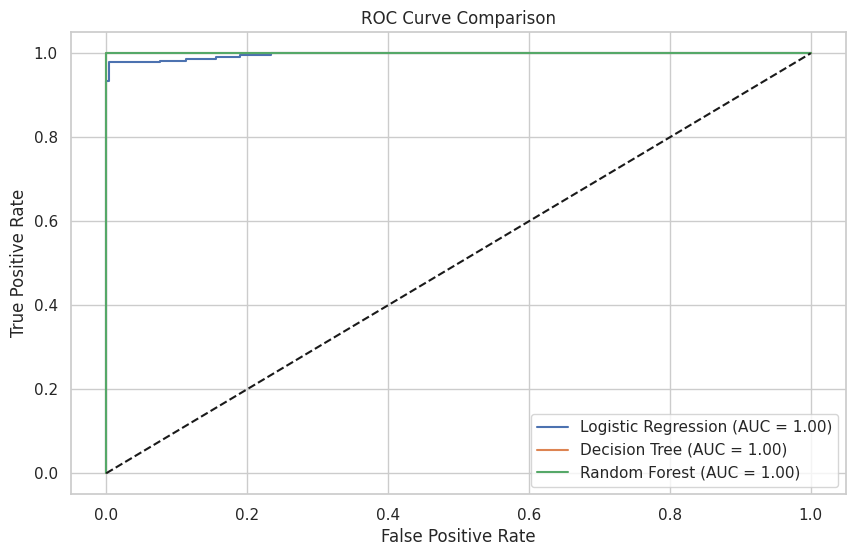

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Convert date
df['date'] = pd.to_datetime(df['date'])

# =========================================
# TARGET CREATION
# =========================================
threshold = df['tavg'].median()
df['target'] = (df['tavg'] > threshold).astype(int)

# =========================================
# FEATURES & LABEL
# =========================================
X = df.drop(columns=['target', 'date'])
y = df['target']

# =========================================
# TRAIN TEST SPLIT (NO LEAKAGE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# LABEL ENCODING (ONLY TRAIN)
# =========================================
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

# =========================================
# REMOVE FULLY NaN COLUMNS
# =========================================
full_nan_cols = X_train.columns[X_train.isnull().all()]

X_train = X_train.drop(columns=full_nan_cols)
X_test = X_test.drop(columns=full_nan_cols)

# =========================================
# HANDLE MISSING VALUES (IMPUTATION)
# =========================================
num_cols = X_train.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='mean')

X_train[num_cols] = pd.DataFrame(
    imputer.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test[num_cols] = pd.DataFrame(
    imputer.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)

# =========================================
# SCALING
# =========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================
# MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# =========================================
# TRAIN + EVALUATE
# =========================================
plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    
    # Classification Report
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================================
# FINAL ROC CURVE
# =========================================
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## Thank you...pls upvote!!!!!!!!!!!!